In [38]:
import numpy as np
import pandas as pd

In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# Display Pipeline

from sklearn import set_config
set_config(display='diagram')

In [40]:
df = pd.read_csv('covid.csv')

In [41]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [42]:
df['has_covid'].value_counts()

has_covid
No     55
Yes    45
Name: count, dtype: int64

In [43]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['has_covid']),df['has_covid'],
                                                test_size=0.2,random_state=42)

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [46]:
X_train

,age,gender,fever,cough,city
55,81,Female,101.0,Mild,Mumbai
88,5,Female,100.0,Mild,Kolkata
26,19,Female,100.0,Mild,Kolkata
42,27,Male,100.0,Mild,Delhi
69,73,Female,103.0,Mild,Delhi
...,...,...,...,...,...
60,24,Female,102.0,Strong,Bangalore
71,75,Female,104.0,Strong,Delhi
14,51,Male,104.0,Mild,Bangalore
92,82,Female,102.0,Strong,Kolkata


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Simple Imputer
trf1 = ColumnTransformer([
    ('si_cols',SimpleImputer(strategy='mean'),[2])
],remainder='passthrough')

In [48]:
X_train_trf1 = trf1.fit_transform(X_train)
X_train_trf1

array([[101.0, 81, 'Female', 'Mild', 'Mumbai'],
       [100.0, 5, 'Female', 'Mild', 'Kolkata'],
       [100.0, 19, 'Female', 'Mild', 'Kolkata'],
       [100.0, 27, 'Male', 'Mild', 'Delhi'],
       [103.0, 73, 'Female', 'Mild', 'Delhi'],
       [103.0, 70, 'Male', 'Strong', 'Kolkata'],
       [102.0, 49, 'Female', 'Mild', 'Delhi'],
       [101.0, 51, 'Female', 'Strong', 'Kolkata'],
       [101.0, 64, 'Female', 'Mild', 'Delhi'],
       [101.0, 83, 'Female', 'Mild', 'Kolkata'],
       [98.0, 65, 'Female', 'Mild', 'Mumbai'],
       [104.0, 18, 'Female', 'Mild', 'Bangalore'],
       [103.0, 16, 'Female', 'Mild', 'Bangalore'],
       [104.0, 16, 'Male', 'Mild', 'Kolkata'],
       [100.0, 27, 'Male', 'Mild', 'Kolkata'],
       [101.0, 84, 'Female', 'Mild', 'Bangalore'],
       [104.0, 51, 'Male', 'Mild', 'Kolkata'],
       [102.0, 69, 'Female', 'Mild', 'Bangalore'],
       [102.0, 82, 'Female', 'Strong', 'Bangalore'],
       [103.0, 69, 'Female', 'Mild', 'Kolkata'],
       [104.0, 44, 'Male',

In [49]:
X_train_trf1.shape

(80, 5)

In [50]:
from sklearn.preprocessing import OneHotEncoder

# one hot encoding
trf2 = ColumnTransformer([
    ('ohe_cols',OneHotEncoder(sparse_output=False,drop='first'),[2,4])
],remainder='passthrough')

In [51]:
X_train_trf2 = trf2.fit_transform(X_train_trf1)
X_train_trf2

array([[0.0, 0.0, 0.0, 1.0, 101.0, 81, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 100.0, 5, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 100.0, 19, 'Mild'],
       [1.0, 1.0, 0.0, 0.0, 100.0, 27, 'Mild'],
       [0.0, 1.0, 0.0, 0.0, 103.0, 73, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 103.0, 70, 'Strong'],
       [0.0, 1.0, 0.0, 0.0, 102.0, 49, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 101.0, 51, 'Strong'],
       [0.0, 1.0, 0.0, 0.0, 101.0, 64, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 101.0, 83, 'Mild'],
       [0.0, 0.0, 0.0, 1.0, 98.0, 65, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 104.0, 18, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 103.0, 16, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 104.0, 16, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 100.0, 27, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 101.0, 84, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 104.0, 51, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 102.0, 69, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 102.0, 82, 'Strong'],
       [0.0, 0.0, 1.0, 0.0, 103.0, 69, 'Mild'],
       [1.0, 0.0, 0.0, 1.0, 104.0, 4

In [52]:
X_train_trf2.shape

(80, 7)

In [53]:
from sklearn.preprocessing import OrdinalEncoder

# ordinal encoding
trf3 = ColumnTransformer([
    ('oe_cols',OrdinalEncoder(categories=[['Mild','Strong']]),[6])
],remainder='passthrough')

In [54]:
X_train_trf3 = trf3.fit_transform(X_train_trf2)
X_train_trf3

array([[0.0, 0.0, 0.0, 0.0, 1.0, 101.0, 81],
       [0.0, 0.0, 0.0, 1.0, 0.0, 100.0, 5],
       [0.0, 0.0, 0.0, 1.0, 0.0, 100.0, 19],
       [0.0, 1.0, 1.0, 0.0, 0.0, 100.0, 27],
       [0.0, 0.0, 1.0, 0.0, 0.0, 103.0, 73],
       [1.0, 1.0, 0.0, 1.0, 0.0, 103.0, 70],
       [0.0, 0.0, 1.0, 0.0, 0.0, 102.0, 49],
       [1.0, 0.0, 0.0, 1.0, 0.0, 101.0, 51],
       [0.0, 0.0, 1.0, 0.0, 0.0, 101.0, 64],
       [0.0, 0.0, 0.0, 1.0, 0.0, 101.0, 83],
       [0.0, 0.0, 0.0, 0.0, 1.0, 98.0, 65],
       [0.0, 0.0, 0.0, 0.0, 0.0, 104.0, 18],
       [0.0, 0.0, 0.0, 0.0, 0.0, 103.0, 16],
       [0.0, 1.0, 0.0, 1.0, 0.0, 104.0, 16],
       [0.0, 1.0, 0.0, 1.0, 0.0, 100.0, 27],
       [0.0, 0.0, 0.0, 0.0, 0.0, 101.0, 84],
       [0.0, 1.0, 0.0, 1.0, 0.0, 104.0, 51],
       [0.0, 0.0, 0.0, 0.0, 0.0, 102.0, 69],
       [1.0, 0.0, 0.0, 0.0, 0.0, 102.0, 82],
       [0.0, 0.0, 0.0, 1.0, 0.0, 103.0, 69],
       [0.0, 1.0, 0.0, 0.0, 1.0, 104.0, 44],
       [0.0, 1.0, 0.0, 0.0, 1.0, 102.0, 74],
       [1.0,

In [55]:
X_train_trf3.shape

(80, 7)

In [56]:
from sklearn.preprocessing import PowerTransformer

# Power Transformer
trf4 = ColumnTransformer([
    ('oe_cols',PowerTransformer(),[0,1,2,3,4,5,6])
],remainder='passthrough')

In [57]:
X_train_trf4 = trf4.fit_transform(X_train_trf3)
X_train_trf4

array([[-0.81649658, -0.83793058, -0.5       , -0.6352234 ,  2.17124059,
         0.01262494,  1.41495371],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -1.88106831],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -0.95016536],
       [-0.81649658,  1.19341628,  2.        , -0.6352234 , -0.46056619,
        -0.51251366, -0.54932751],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         1.04244101,  1.16951806],
       [ 1.22474487,  1.19341628, -0.5       ,  1.5742493 , -0.46056619,
         1.04244101,  1.0746708 ],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.53089138,  0.35698586],
       [ 1.22474487, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
         0.01262494,  0.43013136],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.01262494,  0.87984688],
       [-0.81649658, -0.8379

In [58]:
X_train_trf4.shape

(80, 7)

In [59]:
from sklearn.preprocessing import StandardScaler

# Scaling
trf5 = ColumnTransformer([
    ('scale',StandardScaler(),[0,1,2,3,4,5,6])
#     ('scale',MinMaxScaler(),[0,4,7,8,9,12,13])
])

In [60]:
X_train_trf5 = trf5.fit_transform(X_train_trf4)
X_train_trf5

array([[-0.81649658, -0.83793058, -0.5       , -0.6352234 ,  2.17124059,
         0.01262494,  1.41495371],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -1.88106831],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -0.95016536],
       [-0.81649658,  1.19341628,  2.        , -0.6352234 , -0.46056619,
        -0.51251366, -0.54932751],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         1.04244101,  1.16951806],
       [ 1.22474487,  1.19341628, -0.5       ,  1.5742493 , -0.46056619,
         1.04244101,  1.0746708 ],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.53089138,  0.35698586],
       [ 1.22474487, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
         0.01262494,  0.43013136],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.01262494,  0.87984688],
       [-0.81649658, -0.8379

In [61]:
X_train_trf5.shape

(80, 7)

In [62]:
from sklearn.feature_selection import SelectKBest,mutual_info_classif

# Feature selection
trf6 = SelectKBest(score_func=mutual_info_classif,k=6)

In [63]:
X_train_trf6 = trf6.fit_transform(X_train_trf5,y_train_le)
X_train_trf6

array([[-0.83793058, -0.5       , -0.6352234 ,  2.17124059,  0.01262494,
         1.41495371],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619, -0.51251366,
        -1.88106831],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619, -0.51251366,
        -0.95016536],
       [ 1.19341628,  2.        , -0.6352234 , -0.46056619, -0.51251366,
        -0.54932751],
       [-0.83793058,  2.        , -0.6352234 , -0.46056619,  1.04244101,
         1.16951806],
       [ 1.19341628, -0.5       ,  1.5742493 , -0.46056619,  1.04244101,
         1.0746708 ],
       [-0.83793058,  2.        , -0.6352234 , -0.46056619,  0.53089138,
         0.35698586],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619,  0.01262494,
         0.43013136],
       [-0.83793058,  2.        , -0.6352234 , -0.46056619,  0.01262494,
         0.87984688],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619,  0.01262494,
         1.47473969],
       [-0.83793058, -0.5       , -0.6352234 ,  2.

In [64]:
X_train_trf6.shape

(80, 6)

In [65]:
from sklearn.ensemble import BaggingClassifier

trf7 = BaggingClassifier(max_features=2)

In [66]:
trf7.fit(X_train_trf6,y_train_le)

BaggingClassifier(max_features=2)

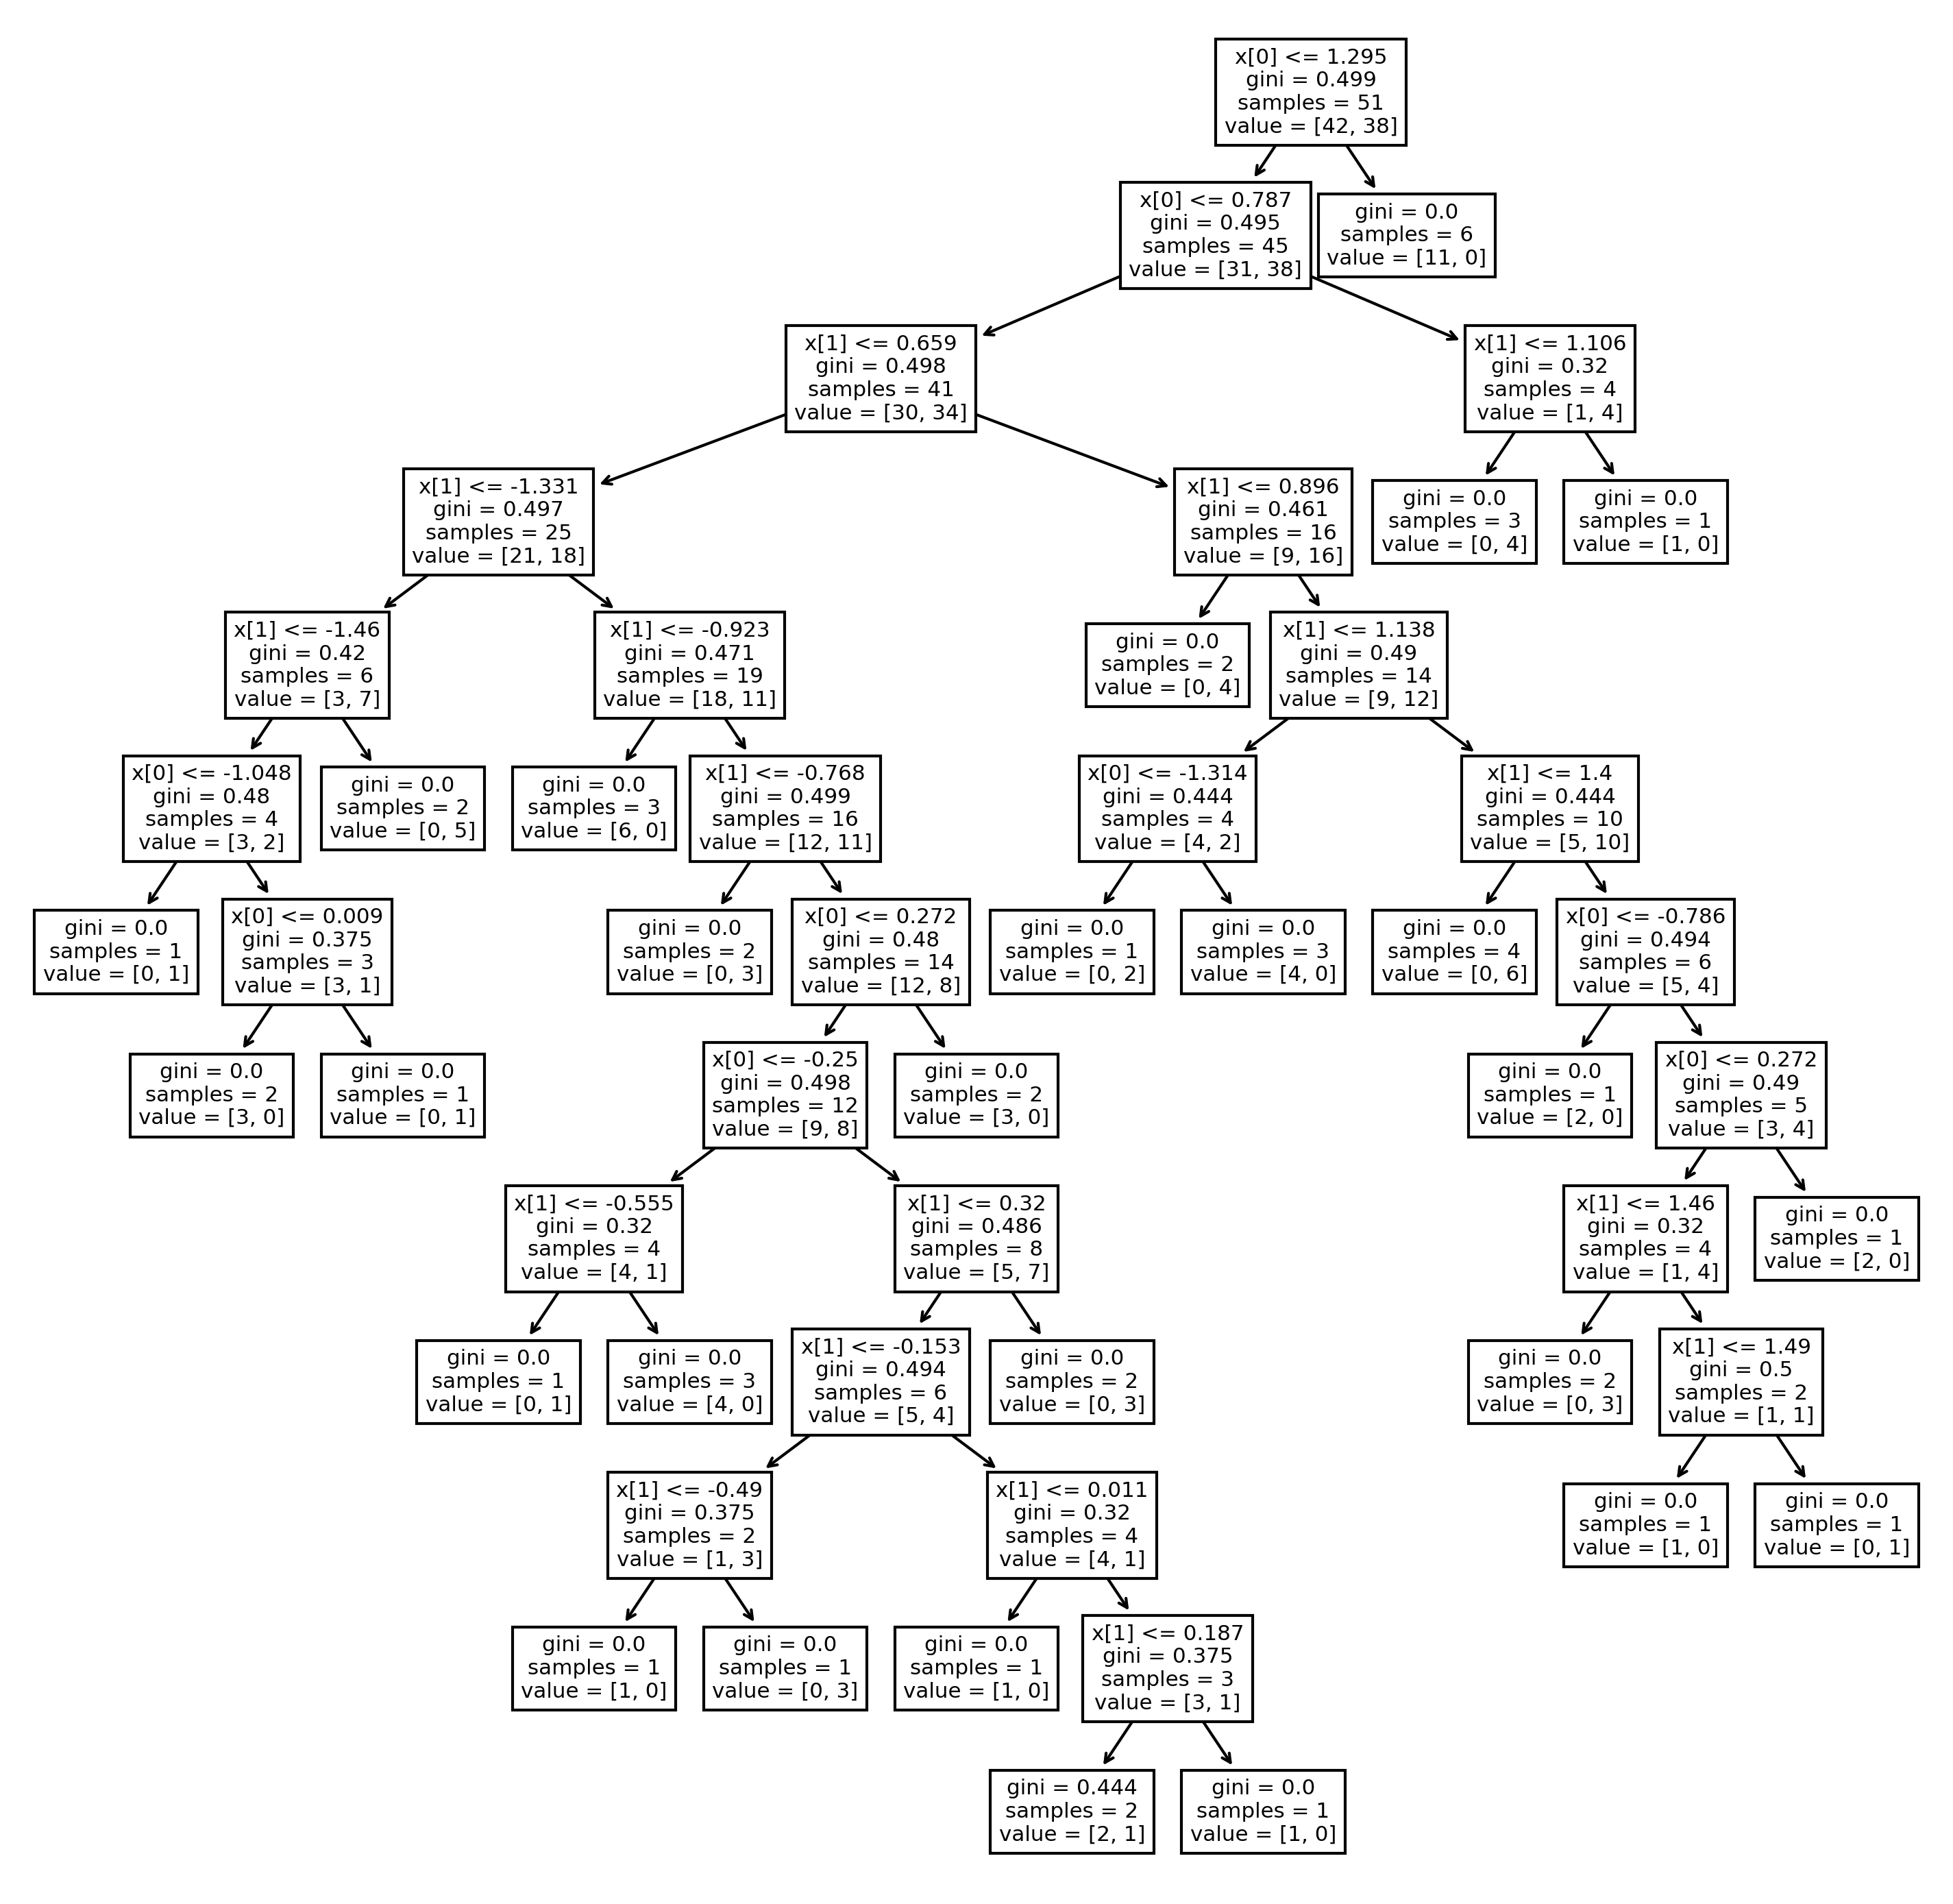

In [67]:
plt.figure(figsize=(12,12))
plot_tree(trf7.estimators_[0])
plt.show()

In [68]:
from sklearn.ensemble import RandomForestClassifier

trf7 = RandomForestClassifier(max_features=2)

In [69]:
trf7.fit(X_train_trf6,y_train_le)

RandomForestClassifier(max_features=2)

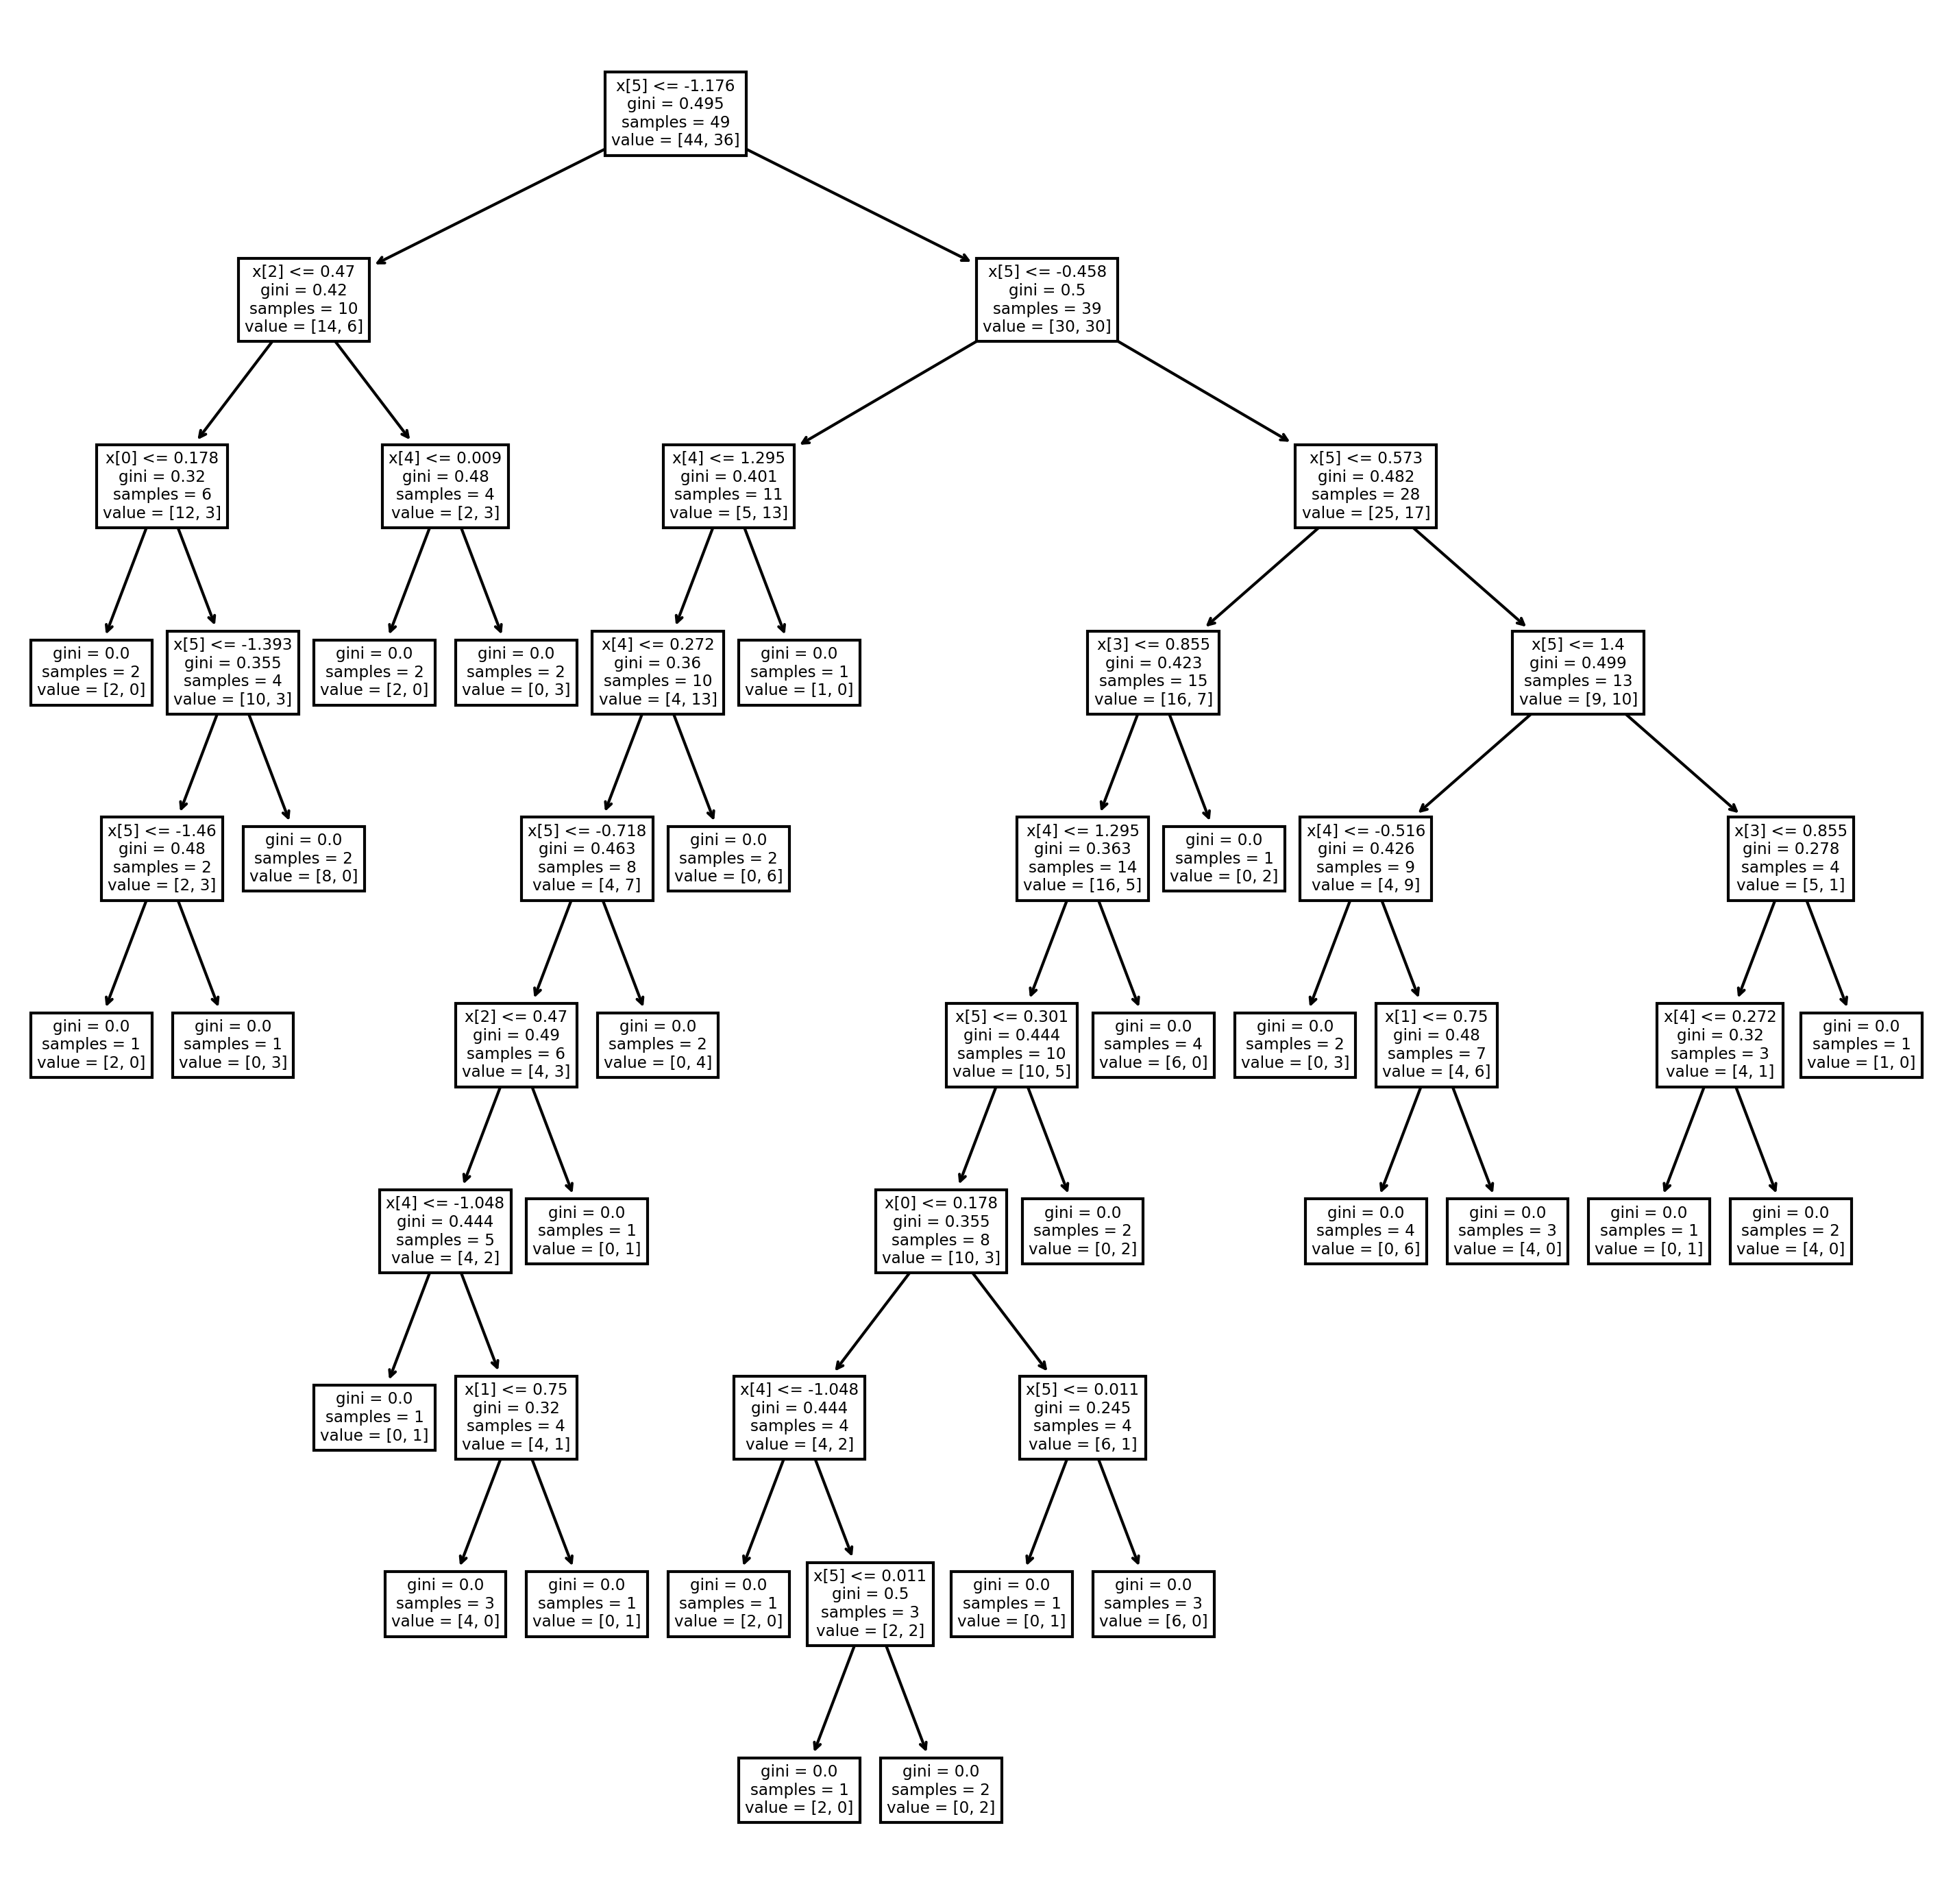

In [70]:
plt.figure(figsize=(12,12))
plot_tree(trf7.estimators_[0])
plt.show()